# 🏥 NumPy & Pandas for Data Scientists
## Case Study: Reducing Hospital Readmission Rates Through Patient Data Analysis

---

### 📚 Objectives

This notebook is a hands-on, end-to-end walkthrough of NumPy and Pandas using a **real-world clinical dataset** of over 100,000 diabetic patient hospital encounters from 130 US hospitals (1999–2008).

| Module | Topic | Tools |
|--------|-------|-------|
| 1 | Loading & First Look | `pd.read_csv`, `df.head`, `df.info` |
| 2 | NumPy Fundamentals | Arrays, vectorised ops, broadcasting |
| 3 | Data Inspection & Quality | Missing values, dtypes, `describe` |
| 4 | Data Cleaning | Replacing, renaming, type conversion |
| 5 | Indexing & Filtering | `loc`, `iloc`, Boolean masks |
| 6 | Feature Engineering | `apply`, `map`, `np.where` |
| 7 | Aggregation & GroupBy | `groupby`, `agg`, pivot tables |
| 8 | Merging & Reshaping | `merge`, `melt`, `pivot` |
| 9 | Statistical Analysis with NumPy | Correlations, distributions |
| 10 | Visualisation-ready Summary | Insight dashboard |

---

### 🔬 Clinical Background

**HbA1c** (Haemoglobin A1c) is a blood test reflecting average blood glucose over 2–3 months. It is a key performance metric for diabetes care. The research question:

> *Does ordering an HbA1c test during a hospital admission reduce the likelihood of a patient being readmitted within 30 days?*

As data scientists, our job is to **explore, clean, and summarise** this dataset to answer that question.

---
## Module 0 — Setup: Import Libraries

In [1]:
# Standard data science imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings

warnings.filterwarnings('ignore')

# Display options — show more columns and rows
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f'NumPy  version: {np.__version__}')
print(f'Pandas version: {pd.__version__}')

NumPy  version: 2.1.3
Pandas version: 2.3.3


---
## Module 1 — Loading & First Look

### 1.1 Reading a CSV with Pandas

`pd.read_csv()` is your primary entry point for tabular data.  
Key parameters to know:

| Parameter | Purpose | Example |
|-----------|---------|--------|
| `filepath_or_buffer` | Path to the file | `'diabetic_data.csv'` |
| `nrows` | Load only N rows (great for big files) | `nrows=1000` |
| `na_values` | Extra strings to treat as NaN | `na_values=['?', 'Unknown']` |
| `dtype` | Specify column types upfront | `dtype={'age': str}` |
| `usecols` | Load only selected columns | `usecols=['age', 'gender']` |

In [2]:
# Load the dataset — treat '?' as a missing value marker
df = pd.read_csv('diabetic_data.csv', na_values=['?'])

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset shape: 101,766 rows × 50 columns


### 1.2 First Peek at the Data

In [3]:
# df.head(n) — first n rows (default 5)
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,...,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,...,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,...,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,...,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,...,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,...,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
# df.tail(n) — last n rows
df.tail(3)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,...,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,MC,NaN,53,0,9,...,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,MC,Surgery-General,45,2,21,...,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),NaN,1,1,7,6,NaN,NaN,13,3,3,...,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO


In [5]:
# df.sample(n) — random rows — important for checking data quality without bias
df.sample(5, random_state=42)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,...,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
35956,110939484,19274094,Caucasian,Female,[70-80),NaN,1,1,6,11,UN,InternalMedicine,68,0,20,...,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
60927,170328306,65634327,Caucasian,Male,[50-60),NaN,1,1,1,1,HM,NaN,20,0,7,...,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
79920,245688426,100657359,Caucasian,Female,[60-70),NaN,3,6,1,4,HM,NaN,21,3,23,...,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
50078,150826224,83144448,Caucasian,Male,[30-40),NaN,2,1,1,12,CP,Gastroenterology,28,0,19,...,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,>30
44080,135993852,65234214,AfricanAmerican,Female,[60-70),NaN,1,2,7,1,NaN,NaN,21,0,6,...,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,<30


### 1.3 Understanding Structure with `df.info()`

`df.info()` is your single most useful first call on any new DataFrame — it shows:
- Number of rows and columns
- Column names and data types (`dtype`)
- Count of non-null values per column (so you can spot missing data instantly)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [7]:
# List all column names neatly
print('Columns:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')

Columns:
   1. encounter_id
   2. patient_nbr
   3. race
   4. gender
   5. age
   6. weight
   7. admission_type_id
   8. discharge_disposition_id
   9. admission_source_id
  10. time_in_hospital
  11. payer_code
  12. medical_specialty
  13. num_lab_procedures
  14. num_procedures
  15. num_medications
  16. number_outpatient
  17. number_emergency
  18. number_inpatient
  19. diag_1
  20. diag_2
  21. diag_3
  22. number_diagnoses
  23. max_glu_serum
  24. A1Cresult
  25. metformin
  26. repaglinide
  27. nateglinide
  28. chlorpropamide
  29. glimepiride
  30. acetohexamide
  31. glipizide
  32. glyburide
  33. tolbutamide
  34. pioglitazone
  35. rosiglitazone
  36. acarbose
  37. miglitol
  38. troglitazone
  39. tolazamide
  40. examide
  41. citoglipton
  42. insulin
  43. glyburide-metformin
  44. glipizide-metformin
  45. glimepiride-pioglitazone
  46. metformin-rosiglitazone
  47. metformin-pioglitazone
  48. change
  49. diabetesMed
  50. readmitted


---
## Module 2 — NumPy Fundamentals

Before diving deeper into Pandas, let us ground ourselves in **NumPy** — the engine powering Pandas under the hood.

### 2.1 NumPy Arrays vs Python Lists

In [8]:
# Python list — flexible but slow for math
py_list = [1, 3, 2, 7, 14, 4, 6]

# NumPy array — fixed type, fast, vectorised
arr = np.array(py_list)

print('Python list:', py_list)
print('NumPy array:', arr)
print('dtype       :', arr.dtype)
print('shape       :', arr.shape)
print('ndim        :', arr.ndim)
print('size        :', arr.size)

Python list: [1, 3, 2, 7, 14, 4, 6]
NumPy array: [ 1  3  2  7 14  4  6]
dtype       : int64
shape       : (7,)
ndim        : 1
size        : 7


In [9]:
# Clinical context: hospital stay lengths (in days) for a sample
stay_lengths = np.array([3, 7, 1, 14, 2, 5, 3, 8, 2, 4, 6, 1, 9, 3, 2])

# Vectorised operations — no loop needed!
print('Stay lengths (days):', stay_lengths)
print('Mean stay          :', stay_lengths.mean())
print('Median stay        :', np.median(stay_lengths))
print('Std deviation      :', stay_lengths.std().round(2))
print('Min / Max          :', stay_lengths.min(), '/', stay_lengths.max())

# Convert to hours (broadcasting — scalar applied to every element)
stay_hours = stay_lengths * 24
print('In hours           :', stay_hours)

Stay lengths (days): [ 3  7  1 14  2  5  3  8  2  4  6  1  9  3  2]
Mean stay          : 4.666666666666667
Median stay        : 3.0
Std deviation      : 3.48
Min / Max          : 1 / 14
In hours           : [ 72 168  24 336  48 120  72 192  48  96 144  24 216  72  48]


### 2.2 Creating Arrays

In [10]:
# Useful array constructors
print('zeros(5)       :', np.zeros(5))
print('ones(5)        :', np.ones(5))
print('arange(1,8)    :', np.arange(1, 8))
print('linspace(0,1,5):', np.linspace(0, 1, 5))

# 2D array — think of it as a mini DataFrame
matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])
print('\n2D array shape:', matrix.shape)
print(matrix)

zeros(5)       : [0. 0. 0. 0. 0.]
ones(5)        : [1. 1. 1. 1. 1.]
arange(1,8)    : [1 2 3 4 5 6 7]
linspace(0,1,5): [0.   0.25 0.5  0.75 1.  ]

2D array shape: (3, 3)
[[1 2 3]
 [4 5 6]
 [7 8 9]]


### 2.3 Vectorised Operations & Boolean Masking

In [11]:
# Boolean mask — find patients with long stays (>7 days)
long_stay_mask = stay_lengths > 7
print('Boolean mask  :', long_stay_mask)
print('Long stays    :', stay_lengths[long_stay_mask])
print('Count         :', long_stay_mask.sum())
print('Percentage    :', f"{long_stay_mask.mean()*100:.1f}%")

Boolean mask  : [False False False  True False False False  True False False False False
  True False False]
Long stays    : [14  8  9]
Count         : 3
Percentage    : 20.0%


In [12]:
# np.where — vectorised if-else (very common in feature engineering)
# Label each stay as 'short' (<4 days) or 'long' (>=4 days)
stay_labels = np.where(stay_lengths < 4, 'short', 'long')
print('Stay labels:', stay_labels)

Stay labels: ['short' 'long' 'short' 'long' 'short' 'long' 'short' 'long' 'short'
 'long' 'long' 'short' 'long' 'short' 'short']


In [13]:
# np.unique — like value_counts but for arrays
unique_vals, counts = np.unique(stay_labels, return_counts=True)
for val, cnt in zip(unique_vals, counts):
    print(f'  {val}: {cnt}')

  long: 7
  short: 8


### 2.4 Relationship Between NumPy and Pandas

Every Pandas column is backed by a NumPy array. You can always extract it with `.values` or `.to_numpy()`.

In [14]:
# Extract a Pandas Series as a NumPy array
time_arr = df['time_in_hospital'].to_numpy()
print('Type    :', type(time_arr))
print('Shape   :', time_arr.shape)
print('Mean stay in hospital:', time_arr.mean().round(2), 'days')
print('25th pct:', np.percentile(time_arr, 25), 'days')
print('75th pct:', np.percentile(time_arr, 75), 'days')

Type    : <class 'numpy.ndarray'>
Shape   : (101766,)
Mean stay in hospital: 4.4 days
25th pct: 2.0 days
75th pct: 6.0 days


---
## Module 3 — Data Inspection & Quality Assessment

Real-world clinical data is messy. Before any analysis, you must **profile** it.

### 3.1 Summary Statistics with `describe()`

In [15]:
# Numeric columns only
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,165201645.62,54330400.69,2.02,3.72,5.75,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,102640295.98,38696359.35,1.45,5.28,4.06,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,12522.00,135.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,84961194.00,23413221.00,1.00,1.00,1.00,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,152388987.00,45505143.00,1.00,1.00,7.00,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,230270887.50,87545949.75,3.00,4.00,7.00,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,443867222.00,189502619.00,8.00,28.00,25.00,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


In [16]:
# Categorical/object columns
df.describe(include='object')

,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,...,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,99493,101766,101766,3197,61510,51817,101745,101408,100343,5346,17018,101766,101766,101766,101766,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,5,3,10,9,17,72,716,748,789,3,3,4,4,4,4,...,4,4,2,3,1,1,4,4,2,2,2,2,2,2,3
top,Caucasian,Female,[70-80),[75-100),MC,InternalMedicine,428,276,250,Norm,>8,No,No,No,No,...,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
freq,76099,54708,26068,1336,32439,14635,6862,6752,11555,2597,8216,81778,100227,101063,101680,...,101458,101728,101763,101727,101766,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864


### 3.2 Missing Value Analysis

Missing data is the norm in healthcare records — fields go unfilled, tests go unordered.  
Always quantify it before deciding how to handle it.

In [17]:
# Count and percentage of missing values per column
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %'    : missing_pct
}).sort_values('Missing %', ascending=False)

# Only show columns that actually have missing values
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


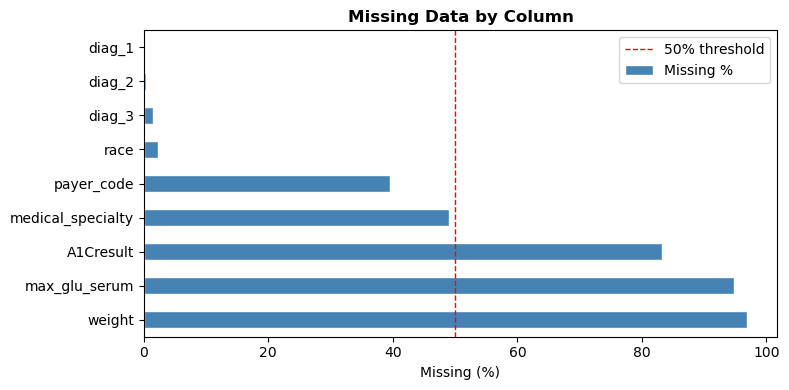


💡 Insight: weight (97% missing) and payer_code are too sparse to use in modelling.


In [18]:
# Visual missing-value summary
cols_with_missing = missing_df[missing_df['Missing Count'] > 0].index.tolist()

fig, ax = plt.subplots(figsize=(8, 4))
missing_df.loc[cols_with_missing, 'Missing %'].plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Data by Column', fontweight='bold')
ax.axvline(50, color='red', linestyle='--', linewidth=1, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.show()

print('\n💡 Insight: weight (97% missing) and payer_code are too sparse to use in modelling.')

### 3.3 Unique Values & Cardinality

In [19]:
# Check cardinality (number of unique values) for object columns
obj_cols = df.select_dtypes(include='object').columns

cardinality = pd.DataFrame({
    'Unique Values': [df[col].nunique() for col in obj_cols],
    'Sample Values': [df[col].dropna().unique()[:4].tolist() for col in obj_cols]
}, index=obj_cols)

cardinality

,Unique Values,Sample Values
race,5,"[Caucasian, AfricanAmerican, Other, Asian]"
gender,3,"[Female, Male, Unknown/Invalid]"
age,10,"[[0-10), [10-20), [20-30), [30-40)]"
weight,9,"[[75-100), [50-75), [0-25), [100-125)]"
payer_code,17,"[MC, MD, HM, UN]"
...,...,...
metformin-rosiglitazone,2,"[No, Steady]"
metformin-pioglitazone,2,"[No, Steady]"
change,2,"[No, Ch]"
diabetesMed,2,"[No, Yes]"


In [20]:
# Our primary outcome variable — readmission status
print('Readmission value counts:')
print(df['readmitted'].value_counts())
print()
print('Proportions:')
print(df['readmitted'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Readmission value counts:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Proportions:
readmitted
NO     53.9%
>30    34.9%
<30    11.2%
Name: proportion, dtype: object


---
## Module 4 — Data Cleaning

### 4.1 Renaming Columns for Clarity

In [21]:
# Work on a copy to preserve the original
dfc = df.copy()

# Rename selected columns for readability
dfc = dfc.rename(columns={
    'patient_nbr'            : 'patient_id',
    'time_in_hospital'       : 'days_in_hospital',
    'num_lab_procedures'     : 'lab_procedures',
    'num_procedures'         : 'procedures',
    'num_medications'        : 'medications',
    'number_outpatient'      : 'prior_outpatient_visits',
    'number_emergency'       : 'prior_emergency_visits',
    'number_inpatient'       : 'prior_inpatient_visits',
    'number_diagnoses'       : 'num_diagnoses',
    'A1Cresult'              : 'hba1c_result',
    'max_glu_serum'          : 'glucose_serum',
    'diabetesMed'            : 'on_diabetes_med',
})

print('Renamed columns:')
print([c for c in dfc.columns[:25]])

Renamed columns:
['encounter_id', 'patient_id', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'days_in_hospital', 'payer_code', 'medical_specialty', 'lab_procedures', 'procedures', 'medications', 'prior_outpatient_visits', 'prior_emergency_visits', 'prior_inpatient_visits', 'diag_1', 'diag_2', 'diag_3', 'num_diagnoses', 'glucose_serum', 'hba1c_result', 'metformin']


### 4.2 Handling Missing Values

In [22]:
# Strategy A — Drop columns with overwhelming missingness
cols_to_drop = ['weight', 'payer_code']
dfc = dfc.drop(columns=cols_to_drop)
print(f'Dropped: {cols_to_drop}')

# Strategy B — Fill categorical NaN with a meaningful label
dfc['race']              = dfc['race'].fillna('Unknown')
dfc['medical_specialty'] = dfc['medical_specialty'].fillna('Unknown')
dfc['hba1c_result']      = dfc['hba1c_result'].fillna('Not Tested')
dfc['glucose_serum']     = dfc['glucose_serum'].fillna('Not Tested')

# Verify — no more missing in those columns
print('\nRemaining missing after cleaning:')
remaining = dfc.isnull().sum()
print(remaining[remaining > 0])

Dropped: ['weight', 'payer_code']

Remaining missing after cleaning:
diag_1      21
diag_2     358
diag_3    1423
dtype: int64


### 4.3 Type Conversion — Encoding the Age Column

The `age` column is a string interval like `[50-60)`. We'll extract the midpoint as a numeric value.

In [23]:
print('Age column before:', dfc['age'].unique())

Age column before: ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']


In [24]:
# Map each bracket to its midpoint
age_midpoint_map = {
    '[0-10)' : 5,  '[10-20)': 15, '[20-30)': 25,
    '[30-40)': 35, '[40-50)': 45, '[50-60)': 55,
    '[60-70)': 65, '[70-80)': 75, '[80-90)': 85,
    '[90-100)': 95
}

dfc['age_midpoint'] = dfc['age'].map(age_midpoint_map)

print('Age midpoint stats:')
print(dfc['age_midpoint'].describe())

Age midpoint stats:
count   101766.00
mean        65.97
std         15.94
min          5.00
25%         55.00
50%         65.00
75%         75.00
max         95.00
Name: age_midpoint, dtype: float64


### 4.4 Encoding the Target Variable

The study defines *early readmission* as being readmitted within 30 days (`<30`).  
We create a binary target column: 1 = early readmission, 0 = no early readmission.

In [25]:
# Binary target: 1 if readmitted <30 days, else 0
dfc['early_readmit'] = (dfc['readmitted'] == '<30').astype(int)

print('Readmission label distribution:')
print(dfc['readmitted'].value_counts())
print()
print('Early readmission rate:', f"{dfc['early_readmit'].mean()*100:.1f}%")

Readmission label distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Early readmission rate: 11.2%


---
## Module 5 — Indexing & Filtering

### 5.1 Column Selection

In [26]:
# Select a single column → returns a Series
hba1c = dfc['hba1c_result']
print(type(hba1c), '\n')

# Select multiple columns → returns a DataFrame
clinical_cols = dfc[['patient_id', 'age', 'age_midpoint', 'hba1c_result',
                      'days_in_hospital', 'early_readmit']]
clinical_cols.head()

<class 'pandas.core.series.Series'> 



,patient_id,age,age_midpoint,hba1c_result,days_in_hospital,early_readmit
0,8222157,[0-10),5,Not Tested,1,0
1,55629189,[10-20),15,Not Tested,3,0
2,86047875,[20-30),25,Not Tested,2,0
3,82442376,[30-40),35,Not Tested,2,0
4,42519267,[40-50),45,Not Tested,1,0


### 5.2 `.loc` — Label-Based Indexing

`df.loc[row_labels, column_labels]` — use when you know column names.

In [27]:
# Select rows 0-4, specific columns
dfc.loc[0:4, ['age', 'hba1c_result', 'days_in_hospital', 'early_readmit']]

,age,hba1c_result,days_in_hospital,early_readmit
0,[0-10),Not Tested,1,0
1,[10-20),Not Tested,3,0
2,[20-30),Not Tested,2,0
3,[30-40),Not Tested,2,0
4,[40-50),Not Tested,1,0


### 5.3 `.iloc` — Integer Position-Based Indexing

`df.iloc[row_positions, column_positions]` — use when you need positional slicing.

In [28]:
# First 5 rows, first 6 columns
dfc.iloc[0:5, 0:6]

,encounter_id,patient_id,race,gender,age,admission_type_id
0,2278392,8222157,Caucasian,Female,[0-10),6
1,149190,55629189,Caucasian,Female,[10-20),1
2,64410,86047875,AfricanAmerican,Female,[20-30),1
3,500364,82442376,Caucasian,Male,[30-40),1
4,16680,42519267,Caucasian,Male,[40-50),1


In [29]:
# Last row, last 3 columns
dfc.iloc[-1, -3:]

readmitted       NO
age_midpoint     75
early_readmit     0
Name: 101765, dtype: object

### 5.4 Boolean Filtering — The Most Common Pattern

In [30]:
# Filter: patients who had an HbA1c test AND were readmitted early
tested_early = dfc[
    (dfc['hba1c_result'] != 'Not Tested') &
    (dfc['early_readmit'] == 1)
]

print(f'Patients tested AND readmitted early: {len(tested_early):,}')
print(tested_early[['age', 'hba1c_result', 'days_in_hospital', 'early_readmit']].head())

Patients tested AND readmitted early: 1,676
         age hba1c_result  days_in_hospital  early_readmit
114  [70-80)         Norm                14              1
116  [60-70)         Norm                 4              1
136  [60-70)           >8                10              1
162  [80-90)         Norm                 5              1
197  [40-50)           >8                 6              1


In [31]:
# Filter using .isin() — multiple allowed values
elderly_patients = dfc[dfc['age'].isin(['[70-80)', '[80-90)', '[90-100)'])]
print(f'Patients aged 70+: {len(elderly_patients):,}')
print(f'Their early readmission rate: {elderly_patients["early_readmit"].mean()*100:.1f}%')

Patients aged 70+: 46,058
Their early readmission rate: 11.8%


In [32]:
# Filter using .query() — SQL-like syntax, clean for complex conditions
high_risk = dfc.query('days_in_hospital >= 7 and age_midpoint >= 65')
print(f'Long-stay elderly patients: {len(high_risk):,}')
print(f'Their early readmission rate: {high_risk["early_readmit"].mean()*100:.1f}%')

Long-stay elderly patients: 15,463
Their early readmission rate: 13.1%


---
## Module 6 — Feature Engineering

Feature engineering transforms raw columns into signals useful for analysis or modelling.

### 6.1 Creating New Columns with Arithmetic

In [33]:
# Total prior healthcare utilisation
dfc['total_prior_visits'] = (
    dfc['prior_outpatient_visits'] +
    dfc['prior_emergency_visits'] +
    dfc['prior_inpatient_visits']
)

# Procedures-per-day ratio (intensity of care)
dfc['procedures_per_day'] = (dfc['procedures'] / dfc['days_in_hospital']).round(2)

print(dfc[['days_in_hospital', 'procedures', 'procedures_per_day', 'total_prior_visits']].head())

   days_in_hospital  procedures  procedures_per_day  total_prior_visits
0                 1           0                0.00                   0
1                 3           0                0.00                   0
2                 2           5                2.50                   3
3                 2           1                0.50                   0
4                 1           0                0.00                   0


### 6.2 Using `np.where` for Conditional Columns

In [34]:
# Categorise HbA1c result into a cleaner clinical label
dfc['hba1c_category'] = np.where(
    dfc['hba1c_result'] == 'Not Tested', 'Not Tested',
    np.where(
        dfc['hba1c_result'] == 'Norm', 'Normal (<7%)',
        np.where(
            dfc['hba1c_result'] == '>7', 'High (7-8%)',
            'Very High (>8%)'
        )
    )
)

print(dfc['hba1c_category'].value_counts())

hba1c_category
Not Tested         84748
Very High (>8%)     8216
Normal (<7%)        4990
High (7-8%)         3812
Name: count, dtype: int64


### 6.3 Using `apply` for Row-wise Logic

In [35]:
# Classify patient risk based on stay length and prior visits
def classify_risk(row):
    if row['days_in_hospital'] >= 7 or row['total_prior_visits'] >= 3:
        return 'High'
    elif row['days_in_hospital'] >= 4 or row['total_prior_visits'] >= 1:
        return 'Medium'
    else:
        return 'Low'

# apply() runs the function for each row (axis=1)
dfc['risk_level'] = dfc.apply(classify_risk, axis=1)

print('Risk level distribution:')
print(dfc['risk_level'].value_counts())

Risk level distribution:
risk_level
Medium    40168
High      33456
Low       28142
Name: count, dtype: int64


In [36]:
# Using .map() to encode gender numerically
dfc['gender_encoded'] = dfc['gender'].map({'Female': 0, 'Male': 1})
# Unknown/Invalid gender becomes NaN — show count
print('Unknown gender:', dfc['gender_encoded'].isna().sum())

Unknown gender: 3


### 6.4 Binning Continuous Variables with `pd.cut`

In [37]:
# Bin the number of medications into clinical tiers
dfc['med_tier'] = pd.cut(
    dfc['medications'],
    bins=[0, 5, 10, 20, 100],
    labels=['Low (1–5)', 'Moderate (6–10)', 'High (11–20)', 'Very High (21+)']
)

print('Medication tier counts:')
print(dfc['med_tier'].value_counts().sort_index())

Medication tier counts:
med_tier
Low (1–5)           5066
Moderate (6–10)    20795
High (11–20)       52025
Very High (21+)    23880
Name: count, dtype: int64


---
## Module 7 — Aggregation & GroupBy

`groupby` is the most powerful Pandas operation for finding patterns in groups.

### 7.1 Basic GroupBy

In [38]:
# Core research question: Does HbA1c testing reduce readmissions?
hba1c_summary = dfc.groupby('hba1c_category').agg(
    num_patients     = ('patient_id', 'count'),
    readmit_rate_pct = ('early_readmit', lambda x: round(x.mean()*100, 2)),
    avg_days         = ('days_in_hospital', 'mean'),
    avg_medications  = ('medications', 'mean')
).round(2)

# Sort by readmission rate
hba1c_summary = hba1c_summary.sort_values('readmit_rate_pct', ascending=False)
hba1c_summary

,num_patients,readmit_rate_pct,avg_days,avg_medications
hba1c_category,,,,
Not Tested,84748,11.42,4.31,15.95
High (7-8%),3812,10.05,4.89,16.84
Very High (>8%),8216,9.87,4.75,16.11
Normal (<7%),4990,9.66,4.92,16.52


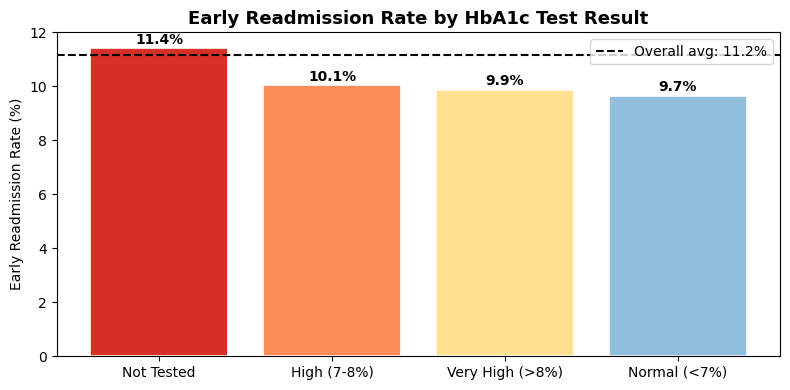

In [39]:
# Visualise the core finding
fig, ax = plt.subplots(figsize=(8, 4))

colors = ['#d73027', '#fc8d59', '#fee090', '#91bfdb']
bars = ax.bar(
    hba1c_summary.index,
    hba1c_summary['readmit_rate_pct'],
    color=colors, edgecolor='white', linewidth=1.2
)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{bar.get_height():.1f}%", ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Early Readmission Rate (%)')
ax.set_title('Early Readmission Rate by HbA1c Test Result', fontweight='bold', fontsize=13)
ax.set_ylim(0, 12)
ax.axhline(dfc['early_readmit'].mean()*100, color='black', linestyle='--',
           linewidth=1.5, label=f"Overall avg: {dfc['early_readmit'].mean()*100:.1f}%")
ax.legend()
plt.tight_layout()
plt.show()

### 7.2 Multi-level GroupBy

In [40]:
# Readmission rate by HbA1c category AND risk level
cross_summary = dfc.groupby(['risk_level', 'hba1c_category'])['early_readmit'].agg(
    count='count',
    readmit_rate=lambda x: (x.mean()*100).round(2)
).reset_index()

cross_summary

,risk_level,hba1c_category,count,readmit_rate
0,High,High (7-8%),1303,13.66
1,High,Normal (<7%),1723,11.49
2,High,Not Tested,27670,15.75
3,High,Very High (>8%),2760,14.02
4,Low,High (7-8%),1029,5.93
5,Low,Normal (<7%),1314,7.46
6,Low,Not Tested,23415,6.81
7,Low,Very High (>8%),2384,6.08
8,Medium,High (7-8%),1480,9.73
9,Medium,Normal (<7%),1953,9.52


### 7.3 GroupBy with Multiple Aggregation Functions — `.agg()`

In [41]:
# Summarise numeric features by age group
age_group_stats = dfc.groupby('age').agg(
    n_patients           = ('patient_id', 'count'),
    mean_stay            = ('days_in_hospital', 'mean'),
    mean_meds            = ('medications', 'mean'),
    mean_lab_procedures  = ('lab_procedures', 'mean'),
    readmit_rate_pct     = ('early_readmit', lambda x: round(x.mean()*100, 1))
).round(2)

age_group_stats

,n_patients,mean_stay,mean_meds,mean_lab_procedures,readmit_rate_pct
age,,,,,
[0-10),161,2.55,6.18,41.01,1.90
[10-20),691,3.19,8.28,43.10,5.80
[20-30),1657,3.56,11.97,43.07,14.20
[30-40),3775,3.80,14.09,43.03,11.20
[40-50),9685,4.04,15.39,42.79,10.60
[50-60),17256,4.13,16.58,42.61,9.70
[60-70),22483,4.38,17.15,42.60,11.10
[70-80),26068,4.59,16.41,43.16,11.80
[80-90),17197,4.81,15.33,44.09,12.10


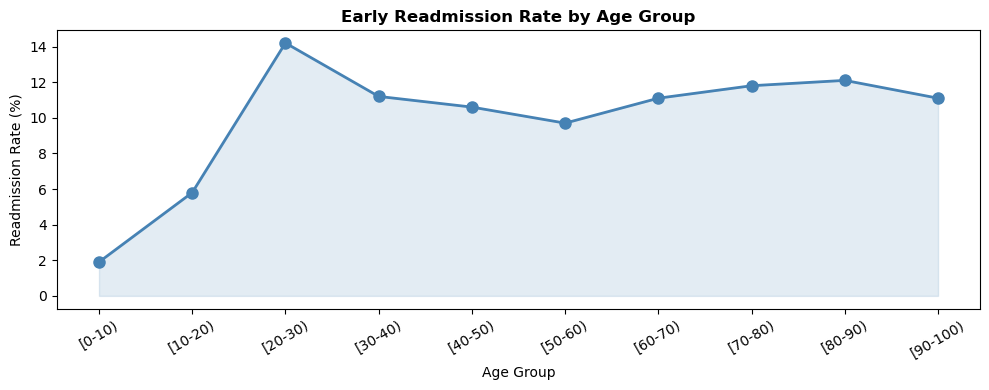

In [42]:
# Plot readmission rate by age group
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(age_group_stats.index, age_group_stats['readmit_rate_pct'],
        marker='o', linewidth=2, color='steelblue', markersize=8)
ax.fill_between(age_group_stats.index,
                age_group_stats['readmit_rate_pct'],
                alpha=0.15, color='steelblue')
ax.set_xlabel('Age Group')
ax.set_ylabel('Readmission Rate (%)')
ax.set_title('Early Readmission Rate by Age Group', fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 7.4 Pivot Tables

Pivot tables cross-tabulate two categorical variables — like a GroupBy on two dimensions at once.

In [43]:
# Pivot: Readmission rate by gender and HbA1c category
pivot = dfc.pivot_table(
    values    = 'early_readmit',
    index     = 'gender',
    columns   = 'hba1c_category',
    aggfunc   = lambda x: f"{x.mean()*100:.1f}%",
    margins   = True,
    margins_name = 'All'
)

print('Early Readmission Rate by Gender × HbA1c Category')
pivot

Early Readmission Rate by Gender × HbA1c Category


hba1c_category,High (7-8%),Normal (<7%),Not Tested,Very High (>8%),All
gender,,,,,
Female,11.1%,9.3%,11.4%,10.4%,11.2%
Male,8.9%,10.1%,11.4%,9.3%,11.1%
Unknown/Invalid,NaN,NaN,0.0%,NaN,0.0%
All,10.0%,9.7%,11.4%,9.9%,11.2%


---
## Module 8 — Merging & Reshaping

### 8.1 Creating a Lookup DataFrame & Merging

In [44]:
# Admission type codes from the dataset documentation
admission_type_lookup = pd.DataFrame({
    'admission_type_id': [1, 2, 3, 4, 5, 6, 7, 8],
    'admission_type_desc': [
        'Emergency', 'Urgent', 'Elective', 'Newborn',
        'Not Available', 'NULL', 'Trauma Center', 'Not Mapped'
    ]
})

# Merge the lookup into our main DataFrame (left join)
dfc = dfc.merge(admission_type_lookup, on='admission_type_id', how='left')

print('Admission type distribution:')
print(dfc['admission_type_desc'].value_counts())

Admission type distribution:
admission_type_desc
Emergency        53990
Elective         18869
Urgent           18480
NULL              5291
Not Available     4785
Not Mapped         320
Trauma Center       21
Newborn             10
Name: count, dtype: int64


### 8.2 Sorting

In [45]:
# Sort by days in hospital (descending), then medications (ascending)
sorted_df = dfc.sort_values(
    by=['days_in_hospital', 'medications'],
    ascending=[False, True]
)

sorted_df[['patient_id', 'days_in_hospital', 'medications',
           'hba1c_category', 'early_readmit']].head(8)

,patient_id,days_in_hospital,medications,hba1c_category,early_readmit
20952,107174142,14,4,Not Tested,0
69225,42007590,14,4,Very High (>8%),0
48658,35556381,14,5,Not Tested,0
17388,18922167,14,6,Not Tested,0
24376,71098857,14,6,Not Tested,0
43759,106691049,14,6,Not Tested,0
72127,100322946,14,6,Normal (<7%),0
7389,720279,14,7,Not Tested,0


### 8.3 Reshaping with `melt` — Wide to Long

In [46]:
# Create a summary wide table
visit_wide = dfc[['patient_id', 'prior_outpatient_visits',
                   'prior_emergency_visits', 'prior_inpatient_visits']].head(5)

print('WIDE format:')
print(visit_wide)

# Melt to long format (useful for plotting)
visit_long = visit_wide.melt(
    id_vars   = 'patient_id',
    var_name  = 'visit_type',
    value_name= 'visit_count'
)

print('\nLONG format:')
print(visit_long)

WIDE format:
   patient_id  prior_outpatient_visits  prior_emergency_visits  \
0     8222157                        0                       0   
1    55629189                        0                       0   
2    86047875                        2                       0   
3    82442376                        0                       0   
4    42519267                        0                       0   

   prior_inpatient_visits  
0                       0  
1                       0  
2                       1  
3                       0  
4                       0  

LONG format:
    patient_id               visit_type  visit_count
0      8222157  prior_outpatient_visits            0
1     55629189  prior_outpatient_visits            0
2     86047875  prior_outpatient_visits            2
3     82442376  prior_outpatient_visits            0
4     42519267  prior_outpatient_visits            0
5      8222157   prior_emergency_visits            0
6     55629189   prior_emergency_visi

---
## Module 9 — Statistical Analysis with NumPy

### 9.1 Distributions of Key Clinical Variables

In [47]:
# Compare distributions of hospital stay for readmitted vs not readmitted
stay_readmit   = dfc.loc[dfc['early_readmit']==1, 'days_in_hospital'].to_numpy()
stay_noreadmit = dfc.loc[dfc['early_readmit']==0, 'days_in_hospital'].to_numpy()

print(f"{'Metric':<25} {'Readmitted':>15} {'Not Readmitted':>18}")
print('-' * 60)
print(f"{'Sample size':<25} {len(stay_readmit):>15,} {len(stay_noreadmit):>18,}")
print(f"{'Mean stay (days)':<25} {stay_readmit.mean():>15.2f} {stay_noreadmit.mean():>18.2f}")
print(f"{'Median stay (days)':<25} {np.median(stay_readmit):>15.2f} {np.median(stay_noreadmit):>18.2f}")
print(f"{'Std deviation':<25} {stay_readmit.std():>15.2f} {stay_noreadmit.std():>18.2f}")
print(f"{'25th percentile':<25} {np.percentile(stay_readmit, 25):>15.2f} {np.percentile(stay_noreadmit, 25):>18.2f}")
print(f"{'75th percentile':<25} {np.percentile(stay_readmit, 75):>15.2f} {np.percentile(stay_noreadmit, 75):>18.2f}")

Metric                         Readmitted     Not Readmitted
------------------------------------------------------------
Sample size                        11,357             90,409
Mean stay (days)                     4.77               4.35
Median stay (days)                   4.00               4.00
Std deviation                        3.03               2.98
25th percentile                      2.00               2.00
75th percentile                      6.00               6.00


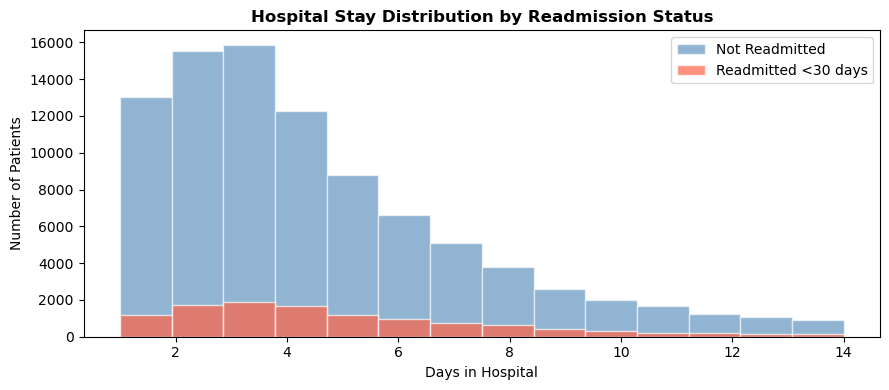

In [48]:
# Histogram comparison
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(stay_noreadmit, bins=14, alpha=0.6, label='Not Readmitted', color='steelblue', edgecolor='white')
ax.hist(stay_readmit,   bins=14, alpha=0.7, label='Readmitted <30 days', color='tomato', edgecolor='white')
ax.set_xlabel('Days in Hospital')
ax.set_ylabel('Number of Patients')
ax.set_title('Hospital Stay Distribution by Readmission Status', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 9.2 Correlation Analysis

In [49]:
# Pearson correlation between numeric variables and early readmission
numeric_cols = ['days_in_hospital', 'lab_procedures', 'procedures',
                'medications', 'num_diagnoses', 'prior_outpatient_visits',
                'prior_emergency_visits', 'prior_inpatient_visits',
                'age_midpoint', 'total_prior_visits']

correlations = dfc[numeric_cols + ['early_readmit']].corr()['early_readmit'].drop('early_readmit')
correlations_sorted = correlations.abs().sort_values(ascending=False)

print('Correlation with Early Readmission (absolute value, descending):')
for col, val in correlations_sorted.items():
    sign = '+' if correlations[col] > 0 else '-'
    bar = '█' * int(abs(val) * 200)
    print(f'  {col:<30} {sign}{abs(val):.4f}  {bar}')

Correlation with Early Readmission (absolute value, descending):
  prior_inpatient_visits         +0.1651  █████████████████████████████████
  total_prior_visits             +0.1261  █████████████████████████
  prior_emergency_visits         +0.0607  ████████████
  num_diagnoses                  +0.0495  █████████
  days_in_hospital               +0.0442  ████████
  medications                    +0.0384  ███████
  lab_procedures                 +0.0204  ████
  prior_outpatient_visits        +0.0189  ███
  age_midpoint                   +0.0176  ███
  procedures                     -0.0122  ██


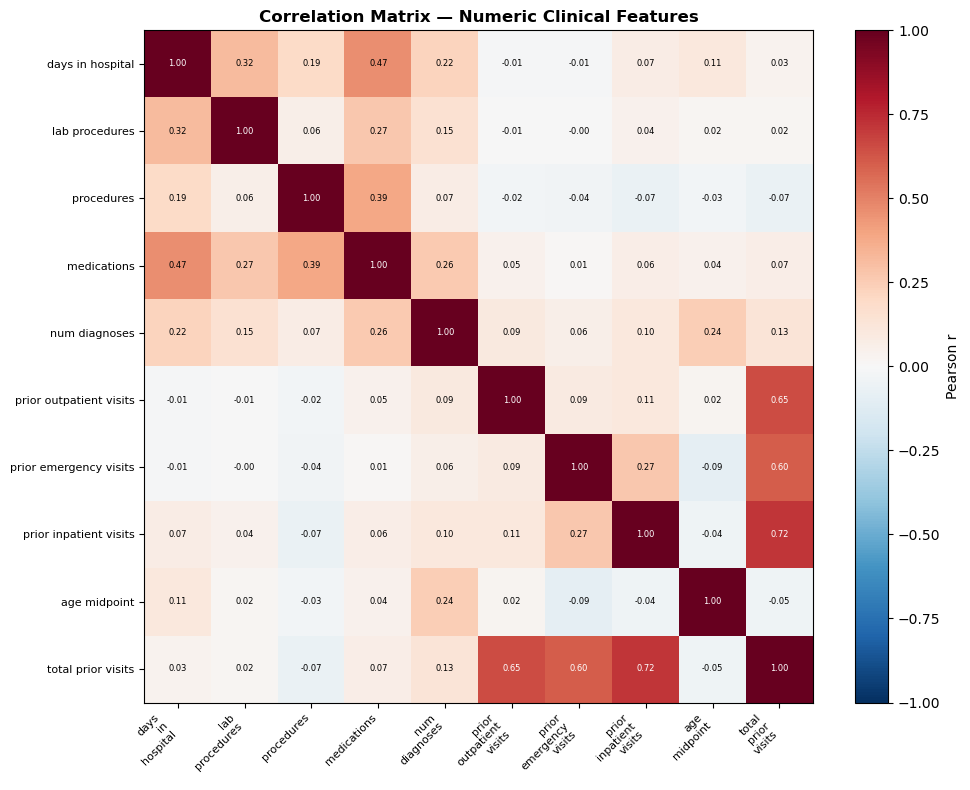

In [50]:
# Correlation heatmap
corr_matrix = dfc[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson r')

ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels([c.replace('_', '\n') for c in numeric_cols], fontsize=8, rotation=45, ha='right')
ax.set_yticklabels([c.replace('_', ' ') for c in numeric_cols], fontsize=8)

# Annotate cells
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        val = corr_matrix.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6,
                color='white' if abs(val) > 0.5 else 'black')

ax.set_title('Correlation Matrix — Numeric Clinical Features', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

### 9.3 NumPy Statistical Deep Dive — Percentile Analysis

Medication count decile breakpoints:
[ 7  9 11 13 15 17 19 22 26]


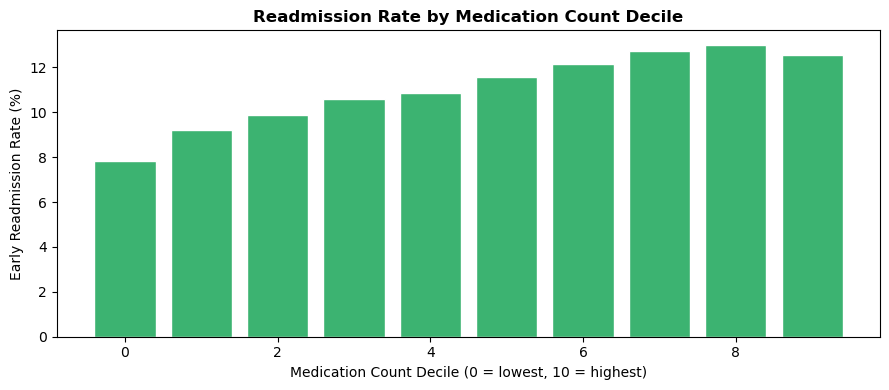

In [51]:
# Decile analysis of medications vs readmission
med_arr = dfc['medications'].to_numpy()
readmit_arr = dfc['early_readmit'].to_numpy()

decile_breaks = np.percentile(med_arr, np.arange(10, 100, 10))
print('Medication count decile breakpoints:')
print(decile_breaks.astype(int))

# Bin patients by medication decile
decile_bins = np.concatenate([[0], decile_breaks, [med_arr.max()+1]])
decile_labels_arr = np.digitize(med_arr, bins=decile_breaks)

# Compute readmission rate per decile using NumPy
decile_rates = [readmit_arr[decile_labels_arr == d].mean()*100
                for d in range(11)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(11), decile_rates, color='mediumseagreen', edgecolor='white')
ax.set_xlabel('Medication Count Decile (0 = lowest, 10 = highest)')
ax.set_ylabel('Early Readmission Rate (%)')
ax.set_title('Readmission Rate by Medication Count Decile', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Module 10 — Insight Dashboard & Summary

### 10.1 Comprehensive Analysis Summary

In [52]:
# --- Admission type readmission summary ---
admit_summary = dfc.groupby('admission_type_desc')['early_readmit'].agg(
    n='count', rate=lambda x: round(x.mean()*100, 2)
).sort_values('rate', ascending=False)

# --- Race readmission summary ---
race_summary = dfc.groupby('race')['early_readmit'].agg(
    n='count', rate=lambda x: round(x.mean()*100, 2)
).sort_values('rate', ascending=False)

# --- Risk level readmission summary ---
risk_summary = dfc.groupby('risk_level')['early_readmit'].agg(
    n='count', rate=lambda x: round(x.mean()*100, 2)
)

print('=== ADMISSION TYPE ===')
print(admit_summary.to_string())
print()
print('=== RACE ===')
print(race_summary.to_string())
print()
print('=== RISK LEVEL ===')
print(risk_summary.to_string())

=== ADMISSION TYPE ===
                         n  rate
admission_type_desc             
Emergency            53990 11.52
Urgent               18480 11.18
NULL                  5291 11.08
Elective             18869 10.39
Not Available         4785 10.34
Newborn                 10 10.00
Not Mapped             320  8.44
Trauma Center           21  0.00

=== RACE ===
                     n  rate
race                        
Caucasian        76099 11.29
AfricanAmerican  19210 11.22
Hispanic          2037 10.41
Asian              641 10.14
Other             1506  9.63
Unknown           2273  8.27

=== RISK LEVEL ===
                n  rate
risk_level             
High        33456 15.30
Low         28142  6.75
Medium      40168 10.80


In [ ]:
# Multi-panel insight dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Hospital Readmission Dashboard\nDiabetic Patient Dataset (n=101,766)', 
             fontsize=14, fontweight='bold', y=1.01)

# Panel 1: HbA1c → Readmission Rate
ax1 = axes[0, 0]
vc = dfc.groupby('hba1c_category')['early_readmit'].mean().mul(100).sort_values(ascending=False)
ax1.barh(vc.index, vc.values, color=['#d73027','#fc8d59','#91bfdb','#4575b4'])
ax1.set_xlabel('Readmission Rate (%)')
ax1.set_title('By HbA1c Test Result', fontweight='bold')
for i, v in enumerate(vc.values):
    ax1.text(v + 0.02, i, f'{v:.1f}%', va='center')

# Panel 2: Age Group → Readmission Rate
ax2 = axes[0, 1]
age_r = dfc.groupby('age')['early_readmit'].mean().mul(100)
ax2.plot(age_r.index, age_r.values, marker='D', linewidth=2.5, color='steelblue', markersize=8)
ax2.fill_between(age_r.index, age_r.values, alpha=0.1, color='steelblue')
ax2.set_ylabel('Readmission Rate (%)')
ax2.set_title('By Age Group', fontweight='bold')
ax2.tick_params(axis='x', rotation=35)

# Panel 3: Risk Level breakdown
ax3 = axes[1, 0]
risk_r = dfc.groupby('risk_level')['early_readmit'].mean().mul(100)
colors_risk = {'Low': '#2ca02c', 'Medium': '#ff7f0e', 'High': '#d62728'}
bars = ax3.bar(risk_r.index, risk_r.values,
               color=[colors_risk[k] for k in risk_r.index], edgecolor='white')
for bar in bars:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{bar.get_height():.1f}%', ha='center', fontweight='bold')
ax3.set_ylabel('Readmission Rate (%)')
ax3.set_title('By Risk Level', fontweight='bold')

# Panel 4: Readmission by number of diagnoses (binned)
ax4 = axes[1, 1]
diag_r = dfc.groupby('num_diagnoses')['early_readmit'].mean().mul(100)
ax4.bar(diag_r.index, diag_r.values, color='mediumpurple', edgecolor='white')
ax4.set_xlabel('Number of Diagnoses')
ax4.set_ylabel('Readmission Rate (%)')
ax4.set_title('By Number of Diagnoses', fontweight='bold')

plt.tight_layout()
plt.savefig('readmission_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved to readmission_dashboard.png')

### 10.2 Final Processed Dataset — Export

In [53]:
# Select the analytical columns for export
export_cols = [
    'encounter_id', 'patient_id', 'gender', 'age', 'age_midpoint', 'race',
    'days_in_hospital', 'lab_procedures', 'procedures', 'medications',
    'num_diagnoses', 'hba1c_result', 'hba1c_category',
    'prior_outpatient_visits', 'prior_emergency_visits', 'prior_inpatient_visits',
    'total_prior_visits', 'procedures_per_day', 'admission_type_desc',
    'on_diabetes_med', 'risk_level', 'med_tier', 'readmitted', 'early_readmit'
]

df_final = dfc[export_cols].copy()

print(f'Final dataset shape: {df_final.shape}')
df_final.head()

Final dataset shape: (101766, 24)


,encounter_id,patient_id,gender,age,age_midpoint,race,days_in_hospital,lab_procedures,procedures,medications,num_diagnoses,hba1c_result,hba1c_category,prior_outpatient_visits,prior_emergency_visits,prior_inpatient_visits,total_prior_visits,procedures_per_day,admission_type_desc,on_diabetes_med,risk_level,med_tier,readmitted,early_readmit
0,2278392,8222157,Female,[0-10),5,Caucasian,1,41,0,1,1,Not Tested,Not Tested,0,0,0,0,0.00,NULL,No,Low,Low (1–5),NO,0
1,149190,55629189,Female,[10-20),15,Caucasian,3,59,0,18,9,Not Tested,Not Tested,0,0,0,0,0.00,Emergency,Yes,Low,High (11–20),>30,0
2,64410,86047875,Female,[20-30),25,AfricanAmerican,2,11,5,13,6,Not Tested,Not Tested,2,0,1,3,2.50,Emergency,Yes,High,High (11–20),NO,0
3,500364,82442376,Male,[30-40),35,Caucasian,2,44,1,16,7,Not Tested,Not Tested,0,0,0,0,0.50,Emergency,Yes,Low,High (11–20),NO,0
4,16680,42519267,Male,[40-50),45,Caucasian,1,51,0,8,5,Not Tested,Not Tested,0,0,0,0,0.00,Emergency,Yes,Low,Moderate (6–10),NO,0


In [54]:
# Save cleaned dataset
df_final.to_csv('diabetic_data_cleaned.csv', index=False)
print('✅ Cleaned dataset saved to diabetic_data_cleaned.csv')

✅ Cleaned dataset saved to diabetic_data_cleaned.csv


---
## 📋 Key Findings Summary

In [55]:
overall_rate = dfc['early_readmit'].mean() * 100
tested_rate  = dfc.loc[dfc['hba1c_result'] != 'Not Tested', 'early_readmit'].mean() * 100
not_tested   = dfc.loc[dfc['hba1c_result'] == 'Not Tested', 'early_readmit'].mean() * 100
high_risk_rate = dfc.loc[dfc['risk_level'] == 'High', 'early_readmit'].mean() * 100
pct_not_tested = (dfc['hba1c_result'] == 'Not Tested').mean() * 100

print('=' * 62)
print('  CLINICAL DATASET ANALYSIS — KEY FINDINGS')
print('  Case Study: Reducing Hospital Readmission Rates')
print('=' * 62)
print(f'  Total patient encounters analysed: {len(dfc):,}')
print(f'  Overall early readmission rate   : {overall_rate:.1f}%')
print()
print('  HbA1c Testing:')
print(f'    Patients NOT tested for HbA1c  : {pct_not_tested:.1f}%')
print(f'    Readmission rate — NOT tested  : {not_tested:.1f}%')
print(f'    Readmission rate — TESTED      : {tested_rate:.1f}%')
print(f'    Difference                     : {not_tested - tested_rate:+.1f} percentage points')
print()
print('  Risk Stratification:')
print(f'    High-risk patient readmission  : {high_risk_rate:.1f}%')
print()
print('  Key NumPy & Pandas Skills Applied:')
print('    ✔ read_csv with na_values       ✔ groupby + agg')
print('    ✔ info / describe / isnull      ✔ pivot_table')
print('    ✔ fillna / dropna / rename      ✔ merge (left join)')
print('    ✔ loc / iloc / boolean filter   ✔ melt (wide → long)')
print('    ✔ apply / map / np.where        ✔ np.percentile / corr')
print('    ✔ pd.cut binning                ✔ vectorised NumPy ops')
print('=' * 62)

  CLINICAL DATASET ANALYSIS — KEY FINDINGS
  Case Study: Reducing Hospital Readmission Rates
  Total patient encounters analysed: 101,766
  Overall early readmission rate   : 11.2%

  HbA1c Testing:
    Patients NOT tested for HbA1c  : 83.3%
    Readmission rate — NOT tested  : 11.4%
    Readmission rate — TESTED      : 9.8%
    Difference                     : +1.6 percentage points

  Risk Stratification:
    High-risk patient readmission  : 15.3%

  Key NumPy & Pandas Skills Applied:
    ✔ read_csv with na_values       ✔ groupby + agg
    ✔ info / describe / isnull      ✔ pivot_table
    ✔ fillna / dropna / rename      ✔ merge (left join)
    ✔ loc / iloc / boolean filter   ✔ melt (wide → long)
    ✔ apply / map / np.where        ✔ np.percentile / corr
    ✔ pd.cut binning                ✔ vectorised NumPy ops


---
## 🏋️ Exercises

Try these on your own to reinforce your learning:

**Exercise 1 — Filtering**  
Find all female patients older than 60 who were NOT tested for HbA1c and had more than 10 medications.  
What is their early readmission rate?

**Exercise 2 — Feature Engineering**  
Create a new column `is_high_med_burden` that is `True` if the patient has more than 15 medications and more than 30 lab procedures. What fraction of such patients were readmitted early?

**Exercise 3 — GroupBy**  
For each `admission_type_desc`, compute: patient count, mean hospital stay, mean medications, and early readmission rate. Sort by readmission rate descending.

**Exercise 4 — NumPy**  
Using only NumPy arrays (no Pandas), compute the 5th, 25th, 50th, 75th, and 95th percentiles of `lab_procedures` for patients who were readmitted early vs not. What do you observe?

**Exercise 5 — Merge**  
Create a discharge disposition lookup table (you can make up labels for IDs 1–6) and merge it into the dataset.  
Which discharge disposition has the highest readmission rate?

---

## 📖 Reference Cheatsheet

| Task | Code |
|------|------|
| Load CSV | `pd.read_csv('file.csv', na_values=['?'])` |
| Quick look | `df.head()`, `df.info()`, `df.describe()` |
| Missing values | `df.isnull().sum()` |
| Select columns | `df[['col1', 'col2']]` |
| Filter rows | `df[df['col'] > value]` |
| Label indexing | `df.loc[0:5, 'col']` |
| Position index | `df.iloc[0:5, 0:3]` |
| New column | `df['new'] = df['a'] + df['b']` |
| Conditional col | `np.where(condition, true_val, false_val)` |
| Apply function | `df['col'].apply(func)` |
| GroupBy | `df.groupby('col').agg({'val': 'mean'})` |
| Pivot table | `df.pivot_table(values, index, columns, aggfunc)` |
| Merge | `df1.merge(df2, on='key', how='left')` |
| Melt | `df.melt(id_vars='id', var_name='name', value_name='val')` |
| Sort | `df.sort_values('col', ascending=False)` |
| Export | `df.to_csv('out.csv', index=False)` |